In [1]:
import xarray as xr
import numpy as np

import sys
sys.path.append('./subroutine')
from rfft2 import rfft2, irfft2
from isospec_rfft import isospec_rfft
from rel_err import rel_err

import matplotlib.pyplot as plt
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1 import ImageGrid
import cmocean.cm as cmo
plt.style.use('/mnt/c/Ryan_Data/Python_Tool/ryan_mplstyle.mplstyle')

########################################################
import jax.numpy as jnp

from jaxparrow import cyclogeostrophy, geostrophy
from jaxparrow.tools import geometry, kinematics, operators
import optax

In [2]:
ds_truth = xr.open_dataset("data/data_channel/processed/truth.nc")
ds_lpfilter = xr.open_dataset("data/data_channel/processed/Fourier_lpfilter.nc")
ds_GeoBal = xr.open_dataset("data/data_channel/processed/Geo_Balanced.nc")

In [3]:
x = ds_truth.x.values
y = ds_truth.y.values

In [4]:
m_per_deglong = 87e3 # how many m per degree long
m_per_deglat = 110e3

x_deg = jnp.asarray(x/m_per_deglong); 
y_deg = jnp.asarray((y-2e5)/m_per_deglat-35);
# lon_t = x_deg; lat_t = y_deg

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [5]:
Eta_jaxsp = jnp.asarray(ds_lpfilter.press_lpfilter.values/ds_truth.g.values)

u_geos, v_geos = geostrophy(Eta_jaxsp, y_deg, x_deg, return_grids=False)

In [6]:
lat_u, lon_u, lat_v, lon_v = geometry.compute_uv_grids(y_deg, x_deg)
norm_vorticity_geos_t = kinematics.normalized_relative_vorticity(u_geos, v_geos, lat_u, lon_u, lat_v, lon_v, interpolate=True)

In [7]:
# cut_id = ds_lpfilter.cut_id.values

# xl = cut_id; xh = -cut_id
# yl = cut_id; yh = -cut_id

# fig,ax = plt.subplots(1,3,figsize=(13,4),layout='constrained',sharey=True)
# zmax = 1

# zbay = norm_vorticity_geos_t[xl:xh,yl:yh]
# zrel = ds_truth.zeta_surface.values[xl:xh,yl:yh]

# im0 = ax[0].pcolor(x[xl:xh,yl:yh]/1e3,y[xl:xh,yl:yh]/1e3,zbay, cmap=cmo.balance, vmin=-zmax, vmax=zmax)
# im1 = ax[1].pcolor(x[xl:xh,yl:yh]/1e3,y[xl:xh,yl:yh]/1e3,zrel-zbay, cmap=cmo.balance, vmin=-zmax, vmax=zmax)
# im2 = ax[2].pcolor(x[xl:xh,yl:yh]/1e3,y[xl:xh,yl:yh]/1e3,zrel, cmap=cmo.balance, vmin=-zmax, vmax=zmax)
# plt.colorbar(im2)

# # print(rel_err(zrel,zqg,1))
# print(rel_err(zrel,zbay,1))

In [8]:
lr_scheduler = optax.exponential_decay(1e-2, 200, .5)  # decrease the learning rate
optim = optax.sgd(learning_rate=lr_scheduler)  # basic SGD works nicely
optim = optax.chain(optax.clip(1), optim)  # prevent updates from exploding

u_cyclo_2d, v_cyclo_2d = cyclogeostrophy(Eta_jaxsp, y_deg, x_deg, optim=optim, return_geos=False, return_grids=False, return_losses=False)

In [9]:
norm_vorticity_var_t = kinematics.normalized_relative_vorticity(u_cyclo_2d, v_cyclo_2d, lat_u, lon_u, lat_v, lon_v, interpolate=True)

0.49046138


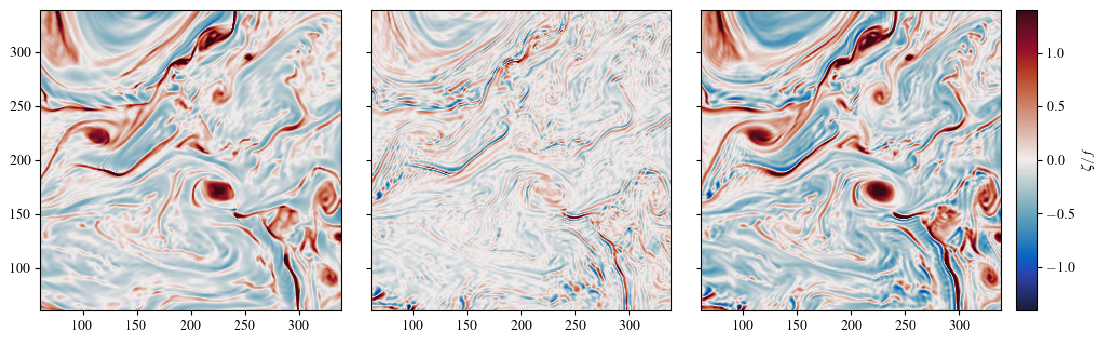

In [12]:
xl = ds_lpfilter.cut_id.values; xh = -ds_lpfilter.cut_id.values
yl = ds_lpfilter.cut_id.values; yh = -ds_lpfilter.cut_id.values

fig = plt.figure(figsize=(9*1.5, 2.6*1.5))

grid = ImageGrid(fig, 111,          # as in plt.subplot(111)
                 nrows_ncols=(1,3),
                 axes_pad=0.3,
                 share_all=True,
                 cbar_location="right",
                 cbar_mode="single",
                 cbar_size="7%",
                 cbar_pad=0.15,
                 )
cmax = 1.4

zeta_CycJAXpar_crop = norm_vorticity_var_t[xl:xh,yl:yh]
zeta_truth_crop = ds_truth.zeta_surface.values[xl:xh,yl:yh]

im0 = grid[0].pcolor(x[xl:xh,yl:yh]/1e3,y[xl:xh,yl:yh]/1e3,zeta_CycJAXpar_crop, cmap=cmo.balance, vmin=-cmax, vmax=cmax)
im1 = grid[1].pcolor(x[xl:xh,yl:yh]/1e3,y[xl:xh,yl:yh]/1e3,zeta_truth_crop-zeta_CycJAXpar_crop, cmap=cmo.balance, vmin=-cmax, vmax=cmax)
im2 = grid[2].pcolor(x[xl:xh,yl:yh]/1e3,y[xl:xh,yl:yh]/1e3,zeta_truth_crop, cmap=cmo.balance, vmin=-cmax, vmax=cmax)

cbar = grid[2].cax.colorbar(im2)
cbar.set_label("$\zeta/f$")

print(rel_err(zeta_truth_crop,zeta_CycJAXpar_crop))

0.5057197342033773
0.49046138
0.3839352122737739


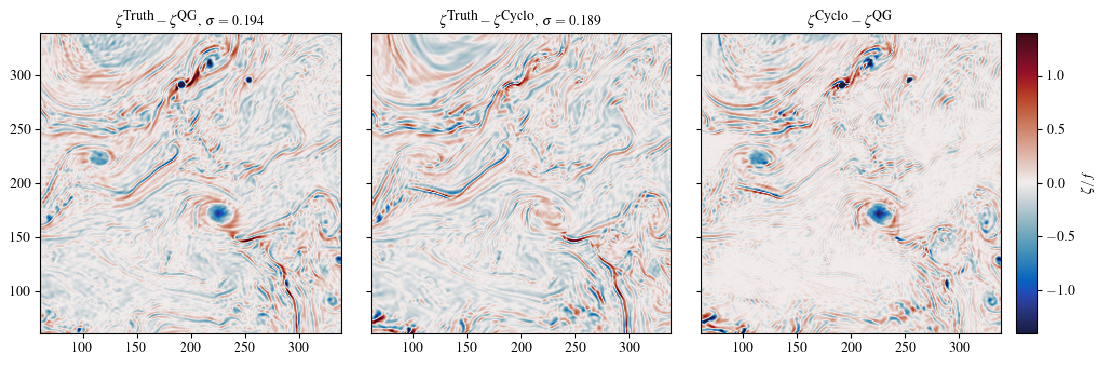

In [18]:
xl = ds_lpfilter.cut_id.values; xh = -ds_lpfilter.cut_id.values
yl = ds_lpfilter.cut_id.values; yh = -ds_lpfilter.cut_id.values

fig = plt.figure(figsize=(9*1.5, 2.6*1.5))

grid = ImageGrid(fig, 111,          # as in plt.subplot(111)
                 nrows_ncols=(1,3),
                 axes_pad=0.3,
                 share_all=True,
                 cbar_location="right",
                 cbar_mode="single",
                 cbar_size="7%",
                 cbar_pad=0.15,
                 )
cmax = 1.4

zeta_GeoBal_crop = ds_GeoBal.zeta_GeoBal.values[xl:xh,yl:yh]

im0 = grid[0].pcolor(x[xl:xh,yl:yh]/1000,y[xl:xh,yl:yh]/1000,zeta_truth_crop-zeta_GeoBal_crop, cmap=cmo.balance, vmin=-cmax, vmax=cmax)
grid[0].set_title(r"$\zeta^\textrm{Truth}-\zeta^\textrm{QG}$, $\sigma=%.3f$" %np.std(zeta_truth_crop-zeta_GeoBal_crop))
im1 = grid[1].pcolor(x[xl:xh,yl:yh]/1000,y[xl:xh,yl:yh]/1000,zeta_truth_crop-zeta_CycJAXpar_crop, cmap=cmo.balance, vmin=-cmax, vmax=cmax)
grid[1].set_title(r"$\zeta^\textrm{Truth}-\zeta^\textrm{Cyclo}$, $\sigma=%.3f$" %np.std(zeta_truth_crop-zeta_CycJAXpar_crop))
im2 = grid[2].pcolor(x[xl:xh,yl:yh]/1000,y[xl:xh,yl:yh]/1000,(zeta_CycJAXpar_crop-zeta_GeoBal_crop), cmap=cmo.balance, vmin=-cmax/1, vmax=cmax/1)
grid[2].set_title(r"$\zeta^\textrm{Cyclo}-\zeta^\textrm{QG}$")

cbar = grid[2].cax.colorbar(im2)
cbar.set_label("$\zeta/f$")

print(rel_err(zeta_truth_crop,zeta_GeoBal_crop))
print(rel_err(zeta_truth_crop,zeta_CycJAXpar_crop))
print(np.std(zeta_truth_crop))

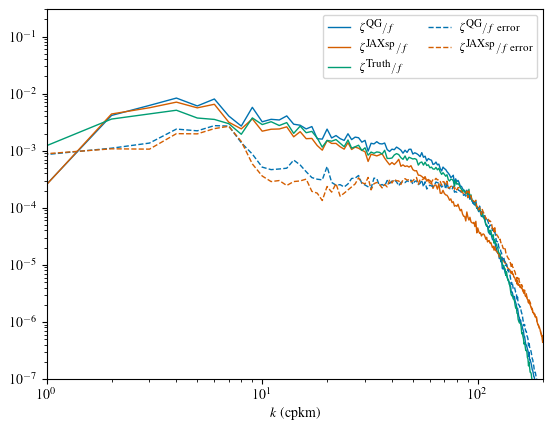

In [14]:
zeta_truth_windowed__ = rfft2(ds_lpfilter.zeta_windowed.values)
zeta_GeoBal__ = rfft2(ds_GeoBal.zeta_GeoBal.values)
zeta_JAXsp__ = rfft2(norm_vorticity_var_t)

zeta_truth_spec = isospec_rfft( np.abs(zeta_truth_windowed__)**2 )
zeta_GeoBal_spec = isospec_rfft( np.abs(zeta_GeoBal__)**2 )
zeta_JAXsp_spec = isospec_rfft( np.abs(zeta_JAXsp__)**2 )

err_JAXsp_spec = isospec_rfft( np.abs(zeta_JAXsp__-zeta_truth_windowed__)**2 )
err_GeoBal_spec = isospec_rfft( np.abs(zeta_GeoBal__-zeta_truth_windowed__)**2 )

plt.loglog(zeta_GeoBal_spec,color=[0,0.4453125,0.6953125],label=r"$\zeta^\textrm{QG}/f$")
plt.loglog(zeta_JAXsp_spec,color=[0.83203125,0.3671875,0.],label=r"$\zeta^\textrm{JAXsp}/f$")
plt.loglog(zeta_truth_spec,color=[0.,0.6171875,0.44921875],label=r"$\zeta^\textrm{Truth}/f$")

plt.loglog(err_GeoBal_spec,'--',color=[0,0.4453125,0.6953125],label=r"$\zeta^\textrm{QG}/f$ error")
plt.loglog(err_JAXsp_spec,'--',color=[0.83203125,0.3671875,0.],label=r"$\zeta^\textrm{JAXsp}/f$ error")

plt.axvline(1/30,color='k')
plt.axvline(1/10,color='k')
# plt.axvline(1/15,color='k')


plt.ylim([1e-7,0.3])
plt.xlim([1,200])
plt.xlabel("$k$ (cpkm)")
plt.legend(ncol=2)

In [15]:
d_save = xr.Dataset(
    
    # dims=["x", "y"],
    coords=dict(
        x=(["x", "y"], ds_truth.x.values),
        y=(["x", "y"], ds_truth.y.values),
    ),
)

d_save["zeta_CycJAXpar"]=(["x", "y"],  norm_vorticity_var_t)

In [16]:
d_save

<xarray.Dataset> Size: 2MB
Dimensions:         (x: 400, y: 400)
Coordinates:
    x               (x, y) float32 640kB 500.0 1.5e+03 ... 3.985e+05 3.995e+05
    y               (x, y) float32 640kB 500.0 500.0 ... 3.995e+05 3.995e+05
Data variables:
    zeta_CycJAXpar  (x, y) float32 640kB -0.0002262 -0.0004236 ... -9.409e-05

In [17]:
d_save.to_netcdf('data/data_channel/processed/Cyclo_JAXparrow.nc')